[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danieldidriksen/Bachelor_Project/blob/main/Fundus_Orientation_Analysis.ipynb)

# Import

In [5]:
try:
    from Image_analysis_class import ImageAnalyzer as IA

except ModuleNotFoundError:
    !git clone https://github.com/danieldidriksen/Bachelor_Project.git
    from Bachelor_Project.Image_analysis_class import ImageAnalyzer as IA

# Part 1 Setup

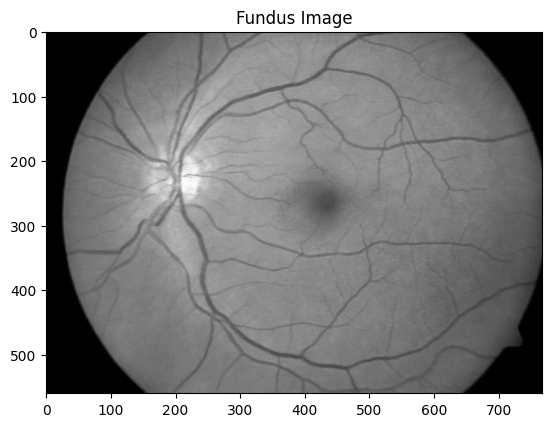

In [6]:
# Insert image here

# For importing image when working in vscode
try:
    imagefile = "Images/Fundus_image.jpg"
    img = IA.load_grayscale(imagefile)[8:-8, :]
# For importing image when working in colab
except:
    imagefile = "Bachelor_Project/Images/Fundas_image.jpg"
    img = IA.load_grayscale(imagefile)[8:-8, :]


IA.plot_image(img, "Fundus Image")

# Part 2: Creating the Structure Tensor

## Computing the structure tensor

In [7]:
S = IA.compute_structure_tensor(img, 1, 2)


# Part 3: Finding the dominant orientation

## Eigen Decomposition

In [8]:
evals, evecs = IA.eigendecomposition(S)

lam_small, lam_large, v_small, v_large  = IA.split_eigenpairs(evals, evecs)

theta = IA.orientation_from_eigenvectors(v_small)

vx, vy = IA.orientation_to_unit_vectors(theta)

## Plotting the Dominant Orientations

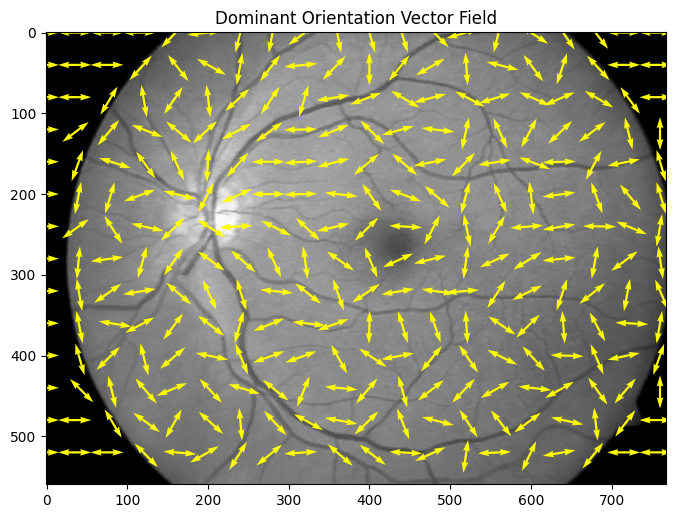

In [9]:
IA.plot_orientation_vectors(img, S, 40)

# Part 4: Histogram and Colour Overlay

## Overlaying on picture

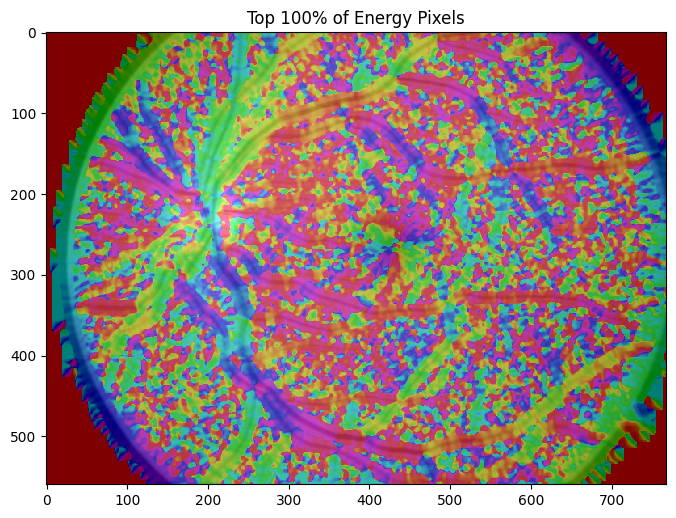

In [10]:
IA.plot_orientation_overlay(img, theta, opaqueness=0.50)

## Making histogram

In [11]:
counts, bin_centers, bin_width = IA.compute_orientation_histogram(theta)

## Plotting histogram

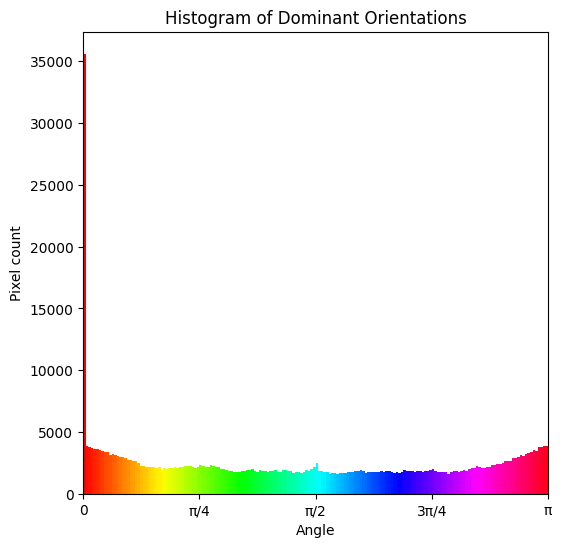

In [12]:
IA.plot_orientation_histogram(counts, bin_centers, bin_width, False)

## Making and plotting polar histogram

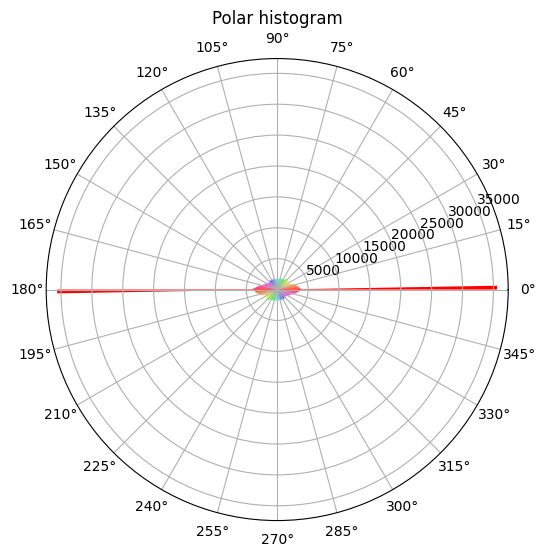

In [13]:
IA.plot_polar_histogram(counts, bin_centers, bin_width, weighted = False)

# Part 5: Isotropy

## Applying Isotropy mask

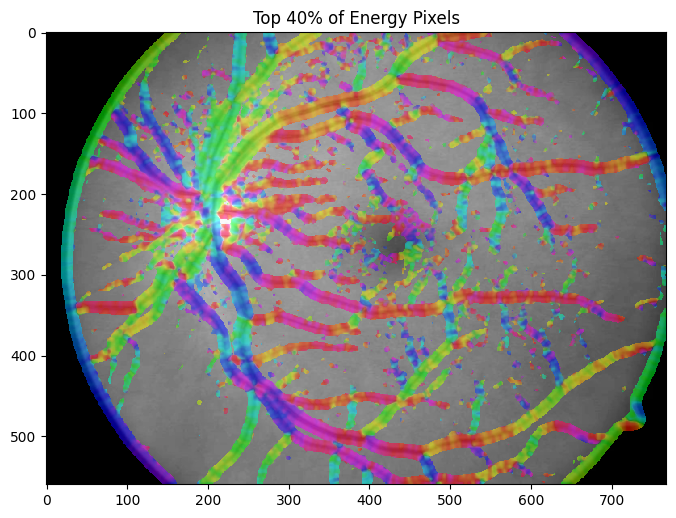

In [14]:
percent = 60
anisotropy_masked = IA.compute_anisotropy_masked(S, percent)
IA.plot_orientation_overlay(img, theta, anisotropy_masked, percent)

## Calculating and plotting weighted Histogram

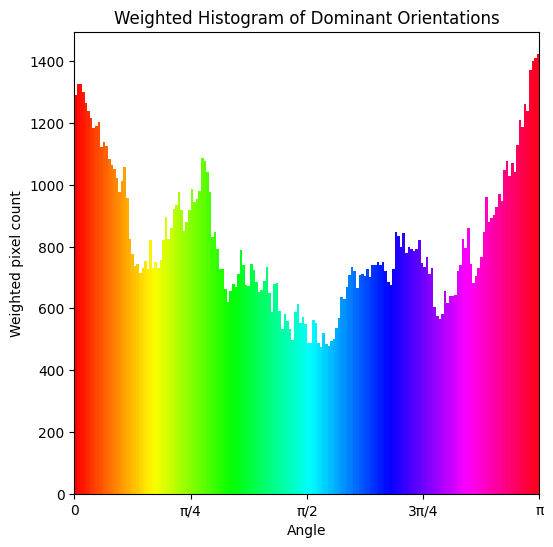

In [15]:
counts, bin_centers, bin_width = IA.compute_orientation_histogram(theta, anisotropy_masked)

IA.plot_orientation_histogram(counts, bin_centers, bin_width, weighted = True)

## Plotting weighted Polar Histogram

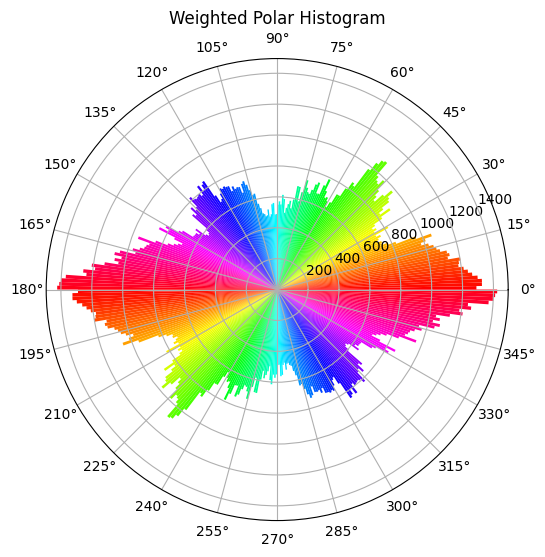

In [16]:
IA.plot_polar_histogram(counts, bin_centers, bin_width, weighted = True)